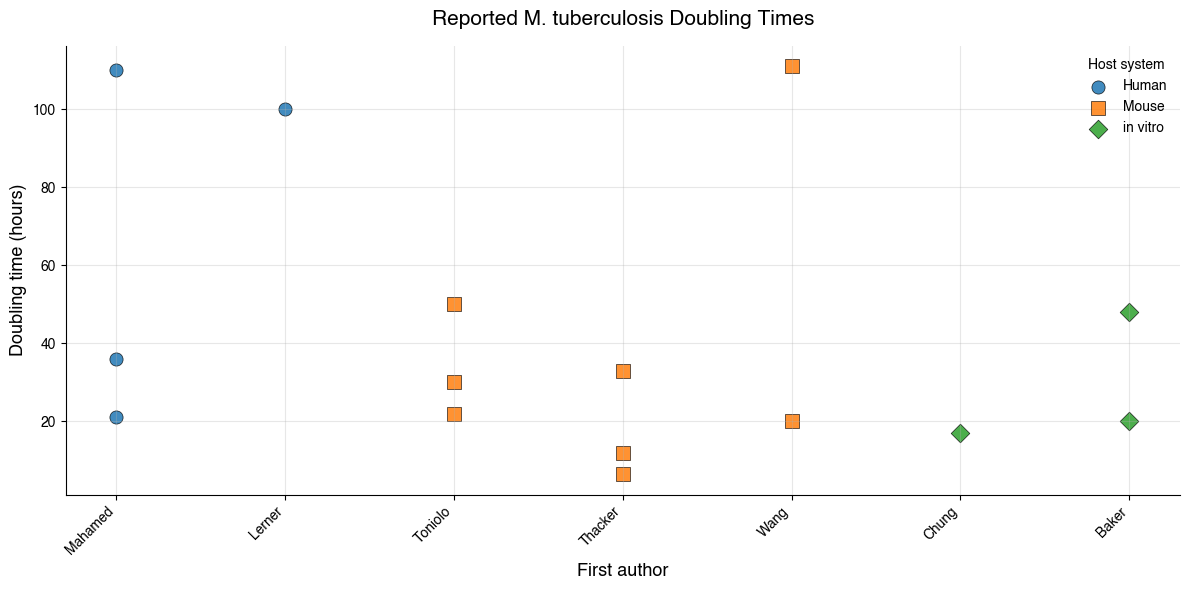

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams

# --- Style settings ---
rcParams["font.family"] = "Helvetica"
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False
rcParams["axes.grid"] = True
rcParams["grid.alpha"] = 0.3

# Data
data = [
    ("Chung", "Chung 2024 Nat Micro", 17, "in vitro"),
    ("Mahamed", "Mahamed 2017 eLife (live MDM)", 110, "Human"),
    ("Mahamed", "Mahamed 2017 eLife (dead MDM)", 21.2, "Human"),
    ("Mahamed", "Mahamed 2017 eLife (extracellular)", 36.1, "Human"),
    ("Toniolo", "Toniolo 2024 (WT intra)", 30, "Mouse"),
    ("Toniolo", "Toniolo 2024 (WT extra)", 22, "Mouse"),
    ("Toniolo", "Toniolo 2024 (ESX1 intra)", 50, "Mouse"),
    ("Lerner", "Lerner 2017 JCB", 100, "Human"),
    ("Thacker", "Thacker 2020 eLife (AT NS)", 12, "Mouse"),
    ("Thacker", "Thacker 2020 eLife (Mac NS)", 33, "Mouse"),
    ("Thacker", "Thacker 2020 eLife (AT/Mac DS)", 6.5, "Mouse"),
    ("Baker", "Baker 2014 Mol Micro (neutral)", 20, "in vitro"),
    ("Baker", "Baker 2014 Mol Micro (acidic, permissive)", 48, "in vitro"),
    ("Wang", "Wang 2019 eLife (acute)", 20, "Mouse"),
    ("Wang", "Wang 2019 eLife (chronic)", 111, "Mouse"),
    # ("Wang", "Wang 2019 eLife (ΔperM chronic)", 280, "Mouse"),
    # ("Gill", "Gill 2009 Nat Med (acute)", 24, "Mouse"),
    # ("Gill", "Gill 2009 Nat Med (chronic)", 100, "Mouse"),
    # ("Muñoz", "Muñoz 2005 Infect Immun (acute)", 24.6, "Mouse"),
    # ("Muñoz", "Muñoz 2005 Infect Immun (chronic)", 1676, "Mouse"),
]

df = pd.DataFrame(data, columns=["Author", "Paper", "DoublingTime_h", "Host"])

# Colors + markers
color_map = {"Human": "tab:blue", "Mouse": "tab:orange", "in vitro": "tab:green"}
marker_map = {"Human": "o", "Mouse": "s", "in vitro": "D"}

# Plot
plt.figure(figsize=(12, 6))
for host, subset in df.groupby("Host"):
    plt.scatter(
        subset["Author"],  # group by first author on x-axis
        subset["DoublingTime_h"],
        label=host,
        color=color_map.get(host, "gray"),
        marker=marker_map.get(host, "o"),
        s=90,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
    )

# plt.yscale("log")
plt.ylabel("Doubling time (hours)", fontsize=13)
plt.xlabel("First author", fontsize=13)
plt.title("Reported M. tuberculosis Doubling Times", fontsize=15, weight="bold", pad=15)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Host system", frameon=False)
plt.tight_layout()
plt.show()

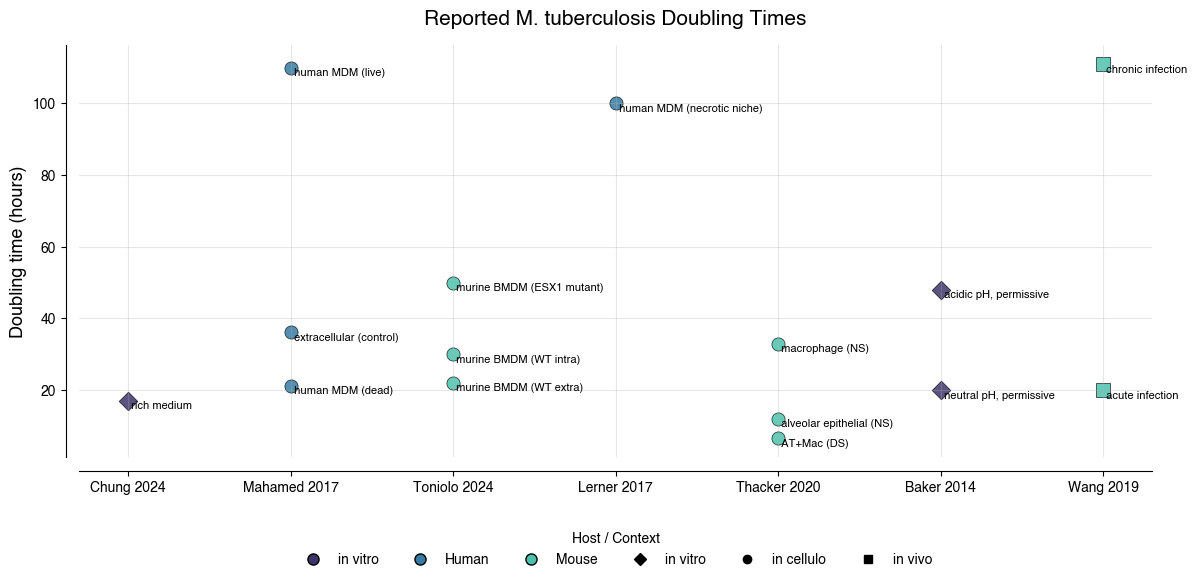

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams
import seaborn as sns

# --- Style settings ---
rcParams["font.family"] = "Helvetica"
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False
rcParams["axes.grid"] = True
rcParams["grid.alpha"] = 0.3

# Data with simplified labels
data = [
    ("Chung", "Chung 2024 Nat Micro", 17, "in vitro", "rich medium", "in vitro", 2024),
    
    ("Mahamed", "Mahamed 2017 eLife (live MDM)", 110, "Human", "human MDM (live)", "in cellulo", 2017),
    ("Mahamed", "Mahamed 2017 eLife (dead MDM)", 21.2, "Human", "human MDM (dead)", "in cellulo", 2017),
    ("Mahamed", "Mahamed 2017 eLife (extracellular)", 36.1, "Human", "extracellular (control)", "in cellulo", 2017),
    
    ("Toniolo", "Toniolo 2024 (WT intra)", 30, "Mouse", "murine BMDM (WT intra)", "in cellulo", 2024),
    ("Toniolo", "Toniolo 2024 (WT extra)", 22, "Mouse", "murine BMDM (WT extra)", "in cellulo", 2024),
    ("Toniolo", "Toniolo 2024 (ESX1 intra)", 50, "Mouse", "murine BMDM (ESX1 mutant)", "in cellulo", 2024),
    
    ("Lerner", "Lerner 2017 JCB", 100, "Human", "human MDM (necrotic niche)", "in cellulo", 2017),
    
    ("Thacker", "Thacker 2020 eLife (AT NS)", 12, "Mouse", "alveolar epithelial (NS)", "in cellulo", 2020),
    ("Thacker", "Thacker 2020 eLife (Mac NS)", 33, "Mouse", "macrophage (NS)", "in cellulo", 2020),
    ("Thacker", "Thacker 2020 eLife (AT/Mac DS)", 6.5, "Mouse", "AT+Mac (DS)", "in cellulo", 2020),
    
    ("Baker", "Baker 2014 Mol Micro (neutral)", 20, "in vitro", "neutral pH, permissive", "in vitro", 2014),
    ("Baker", "Baker 2014 Mol Micro (acidic, permissive)", 48, "in vitro", "acidic pH, permissive", "in vitro", 2014),
    
    ("Wang", "Wang 2019 eLife (acute)", 20, "Mouse", "acute infection", "in vivo", 2019),
    ("Wang", "Wang 2019 eLife (chronic)", 111, "Mouse", "chronic infection", "in vivo", 2019),
]

df = pd.DataFrame(data, columns=["Author", "Paper", "DoublingTime_h", "Host", "Label", "Context", "Year"])

# Add combined Author+Year column for x-axis
df["AuthorYear"] = df["Author"] + " " + df["Year"].astype(str)

# Host color palette (mako)
palette = sns.color_palette("mako", n_colors=df["Host"].nunique())
color_map = dict(zip(df["Host"].unique(), palette))

# Context marker mapping
context_map = {"in vitro": "D", "in cellulo": "o", "in vivo": "s"}  # diamond, circle, square

# Plot
plt.figure(figsize=(12, 6))
for _, row in df.iterrows():
    plt.scatter(
        row["AuthorYear"],
        row["DoublingTime_h"],
        color=color_map[row["Host"]],
        marker=context_map[row["Context"]],
        s=90,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
    )

    # Add simplified condition label text
    plt.text(
        row["AuthorYear"],
        row["DoublingTime_h"],
        f" {row['Label']}",
        fontsize=8,
        ha="left",
        va="top",
        rotation=0
    )

# y-axis (log scale recommended)
# plt.yscale("log")
plt.ylabel("Doubling time (hours)", fontsize=13)
# plt.xlabel("First author (Year)", fontsize=13)
plt.title("Reported M. tuberculosis Doubling Times", fontsize=15, weight="bold", pad=15)

plt.xticks(rotation=45, ha="right")

# Legends
host_patches = [plt.Line2D([0], [0], marker="o", color="w",
                           markerfacecolor=color_map[h], markersize=8, markeredgecolor="black",
                           label=h) for h in df["Host"].unique()]

context_patches = [plt.Line2D([0], [0], marker=m, color="k", linestyle="",
                              label=ctx) for ctx, m in context_map.items()]

plt.legend(
    handles=host_patches + context_patches,
    title="Host / Context",
    frameon=False,
    bbox_to_anchor=(0.5, -0.15),  # move below the plot
    loc="upper center",
    ncol=len(host_patches + context_patches)  # put all entries in one row
)
plt.tight_layout()
sns.despine(offset=10)
plt.show()